In [7]:
import sys
from pathlib import Path
import importlib

%load_ext autoreload
%autoreload 2

current = Path.cwd()

if (current / "ultrasound_tracker").exists():
    PROJECT_ROOT = current
elif (current.parent / "ultrasound_tracker").exists():
    PROJECT_ROOT = current.parent
else:
    raise FileNotFoundError("Could not find ultrasound_tracker folder")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PROJECT_ROOT = /Users/grosbedou/PycharmProjects/NDORMS


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

import ultrasound_tracker.roi as roi
import ultrasound_tracker.geometry as geom
import ultrasound_tracker.utils as ut

from ultrasound_tracker.legacy.klt_tracker import KLTTracker

roi = importlib.reload(roi)
geom = importlib.reload(geom)
ut = importlib.reload(ut)

print("ROI file:", roi.__file__)
print("Geometry file:", geom.__file__)
print("Utils file:", ut.__file__)

print("geometry compute:", hasattr(geom, "compute_fascicle_geometry"))
print("utils draw:", hasattr(ut, "draw_line_on_image"))

ROI file: /Users/grosbedou/PycharmProjects/NDORMS/ultrasound_tracker/roi.py
Geometry file: /Users/grosbedou/PycharmProjects/NDORMS/ultrasound_tracker/geometry.py
Utils file: /Users/grosbedou/PycharmProjects/NDORMS/ultrasound_tracker/utils.py
geometry compute: True
utils draw: True


In [9]:
VIDEO_PATH = PROJECT_ROOT / "data" / "raw" / "UltraTimTrack_test.mp4"
ROI_PATH = PROJECT_ROOT / "data" / "rois" / "UltraTimTrack_test_rois.json"

TIMTRACK_NPZ = PROJECT_ROOT / "results" / "timtrack_sequence_features_arrays.npz"

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

OUT_CSV = RESULTS_DIR / "klt_sequence_features.csv"
OUT_NPZ = RESULTS_DIR / "klt_sequence_features_arrays.npz"

print("VIDEO_PATH:", VIDEO_PATH)
print("TIMTRACK_NPZ:", TIMTRACK_NPZ)
print("OUT_CSV:", OUT_CSV)
print("OUT_NPZ:", OUT_NPZ)

VIDEO_PATH: /Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4
TIMTRACK_NPZ: /Users/grosbedou/PycharmProjects/NDORMS/results/timtrack_sequence_features_arrays.npz
OUT_CSV: /Users/grosbedou/PycharmProjects/NDORMS/results/klt_sequence_features.csv
OUT_NPZ: /Users/grosbedou/PycharmProjects/NDORMS/results/klt_sequence_features_arrays.npz


In [10]:
rois = roi.load_rois(ROI_PATH)

cap = cv2.VideoCapture(str(VIDEO_PATH))
fps = cap.get(cv2.CAP_PROP_FPS)
n_video_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

ret, frame0 = cap.read()
cap.release()

if not ret:
    raise RuntimeError(f"Could not read video: {VIDEO_PATH}")

if frame0.ndim == 3:
    frame0_gray = cv2.cvtColor(frame0, cv2.COLOR_BGR2GRAY)
else:
    frame0_gray = frame0.copy()

tim = np.load(TIMTRACK_NPZ, allow_pickle=True)

print("FPS:", fps)
print("Video frames:", n_video_frames)
print("Frame shape:", frame0_gray.shape)
print("ROIs:", rois)

print("\nTimTrack keys:")
for key in tim.files:
    print(" -", key, tim[key].shape)

FPS: 33.341
Video frames: 2667
Frame shape: (562, 706)
ROIs: {'superficial': (15, 21, 690, 42), 'deep': (16, 298, 689, 76), 'fascicle': (17, 65, 686, 226)}

TimTrack keys:
 - frame (2667,)
 - time_s (2667,)
 - success (2667,)
 - sup_apo_lines (2667, 4)
 - deep_apo_lines (2667, 4)
 - fascicle_lines (2667, 4)
 - fascicle_segments (2667, 4)
 - sup_attachments (2667, 2)
 - deep_attachments (2667, 2)
 - fascicle_length_px (2667,)
 - fascicle_angle_deg (2667,)
 - deep_apo_angle_deg (2667,)
 - pennation_angle_deg (2667,)
 - n_fascicle_candidates (2667,)


In [11]:
frames_arr = tim["frame"].astype(int)
time_arr = tim["time_s"].astype(np.float32)
tim_success = tim["success"].astype(bool)

tim_sup_apo_lines = tim["sup_apo_lines"].astype(np.float32)
tim_deep_apo_lines = tim["deep_apo_lines"].astype(np.float32)
tim_fascicle_lines = tim["fascicle_lines"].astype(np.float32)
tim_fascicle_segments = tim["fascicle_segments"].astype(np.float32)
tim_sup_attachments = tim["sup_attachments"].astype(np.float32)
tim_deep_attachments = tim["deep_attachments"].astype(np.float32)

tim_length = tim["fascicle_length_px"].astype(np.float32)
tim_fascicle_angle = tim["fascicle_angle_deg"].astype(np.float32)
tim_deep_apo_angle = tim["deep_apo_angle_deg"].astype(np.float32)
tim_pennation = tim["pennation_angle_deg"].astype(np.float32)

print("Number of TimTrack results:", len(frames_arr))
print("TimTrack success rate:", 100 * np.mean(tim_success), "%")

valid_tim_indices = np.where(tim_success)[0]

if len(valid_tim_indices) == 0:
    raise RuntimeError("No successful TimTrack frames available.")

initial_result_idx = int(valid_tim_indices[0])
initial_frame_idx = int(frames_arr[initial_result_idx])

print("Initial result index:", initial_result_idx)
print("Initial video frame:", initial_frame_idx)

Number of TimTrack results: 2667
TimTrack success rate: 100.0 %
Initial result index: 0
Initial video frame: 0


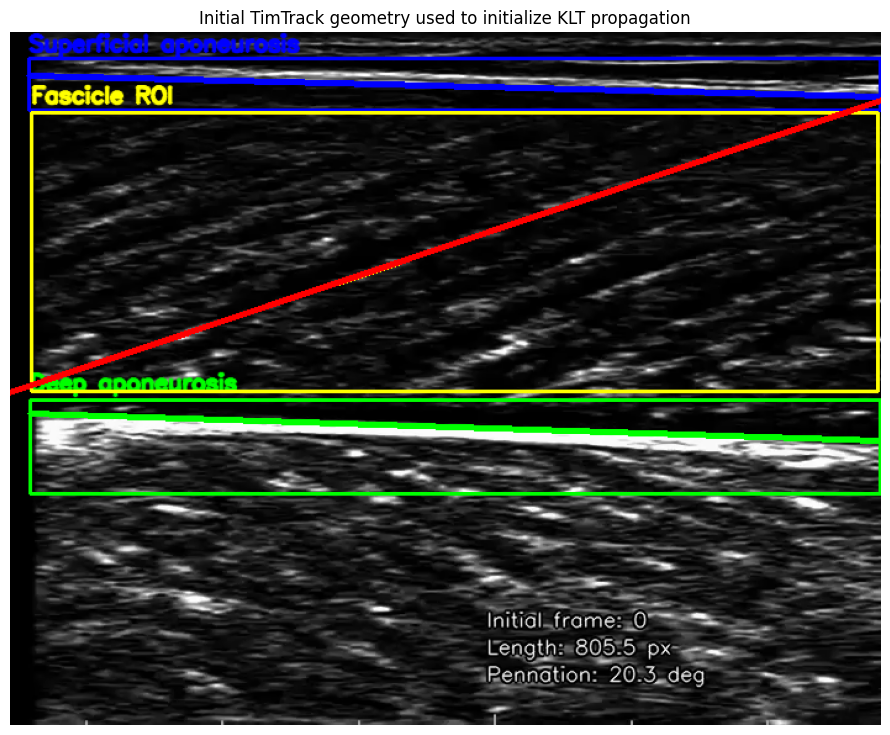

In [12]:
cap = cv2.VideoCapture(str(VIDEO_PATH))
cap.set(cv2.CAP_PROP_POS_FRAMES, initial_frame_idx)
ret, init_frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError(f"Could not read initial frame {initial_frame_idx}")

if init_frame.ndim == 3:
    init_gray = cv2.cvtColor(init_frame, cv2.COLOR_BGR2GRAY)
else:
    init_gray = init_frame.copy()

vis_init = roi.draw_rois(init_gray, rois)

ut.draw_line_on_image(vis_init, tim_sup_apo_lines[initial_result_idx], color=(255, 0, 0), thickness=3)
ut.draw_line_on_image(vis_init, tim_deep_apo_lines[initial_result_idx], color=(0, 255, 0), thickness=3)
ut.draw_line_on_image(vis_init, tim_fascicle_lines[initial_result_idx], color=(0, 255, 255), thickness=3)
ut.draw_line_on_image(vis_init, tim_fascicle_segments[initial_result_idx], color=(0, 0, 255), thickness=4)

ut.draw_points_on_image(
    vis_init,
    np.vstack([
        tim_sup_attachments[initial_result_idx],
        tim_deep_attachments[initial_result_idx],
    ]),
    color=(0, 0, 255),
    radius=6,
)

text_lines = [
    f"Initial frame: {initial_frame_idx}",
    f"Length: {tim_length[initial_result_idx]:.1f} px",
    f"Pennation: {tim_pennation[initial_result_idx]:.1f} deg",
]

ut.put_text_lines_on_image(
    vis_init,
    text_lines,
    origin=(init_gray.shape[1] - 320, init_gray.shape[0] - 80),
    line_spacing=22,
    font_scale=0.55,
    color=(255, 255, 255),
    outline_color=(0, 0, 0),
)

plt.figure(figsize=(16, 9))
plt.imshow(vis_init[..., ::-1])
plt.title("Initial TimTrack geometry used to initialize KLT propagation")
plt.axis("off")
plt.show()

In [15]:
n_results = len(frames_arr)

klt_success = np.zeros(n_results, dtype=bool)
klt_error = np.array([""] * n_results, dtype=object)

klt_sup_apo_lines = np.full((n_results, 4), np.nan, dtype=np.float32)
klt_deep_apo_lines = np.full((n_results, 4), np.nan, dtype=np.float32)
klt_fascicle_lines = np.full((n_results, 4), np.nan, dtype=np.float32)
klt_fascicle_segments = np.full((n_results, 4), np.nan, dtype=np.float32)
klt_sup_attachments = np.full((n_results, 2), np.nan, dtype=np.float32)
klt_deep_attachments = np.full((n_results, 2), np.nan, dtype=np.float32)

klt_length = np.full(n_results, np.nan, dtype=np.float32)
klt_fascicle_angle = np.full(n_results, np.nan, dtype=np.float32)
klt_deep_apo_angle = np.full(n_results, np.nan, dtype=np.float32)
klt_pennation = np.full(n_results, np.nan, dtype=np.float32)

klt_dx = np.full(n_results, np.nan, dtype=np.float32)
klt_dy = np.full(n_results, np.nan, dtype=np.float32)
klt_n_points = np.zeros(n_results, dtype=np.int32)
klt_affine_used = np.zeros(n_results, dtype=bool)

In [16]:
# Geometry at initial frame = TimTrack geometry.
klt_sup_apo_lines[initial_result_idx] = tim_sup_apo_lines[initial_result_idx]
klt_deep_apo_lines[initial_result_idx] = tim_deep_apo_lines[initial_result_idx]
klt_fascicle_lines[initial_result_idx] = tim_fascicle_lines[initial_result_idx]
klt_fascicle_segments[initial_result_idx] = tim_fascicle_segments[initial_result_idx]
klt_sup_attachments[initial_result_idx] = tim_sup_attachments[initial_result_idx]
klt_deep_attachments[initial_result_idx] = tim_deep_attachments[initial_result_idx]

klt_length[initial_result_idx] = tim_length[initial_result_idx]
klt_fascicle_angle[initial_result_idx] = tim_fascicle_angle[initial_result_idx]
klt_deep_apo_angle[initial_result_idx] = tim_deep_apo_angle[initial_result_idx]
klt_pennation[initial_result_idx] = tim_pennation[initial_result_idx]

klt_success[initial_result_idx] = True

prev_sup_line = klt_sup_apo_lines[initial_result_idx].copy()
prev_deep_line = klt_deep_apo_lines[initial_result_idx].copy()
prev_fascicle_line = klt_fascicle_lines[initial_result_idx].copy()

print("KLT geometry initialized from TimTrack at frame", initial_frame_idx)

KLT geometry initialized from TimTrack at frame 0


In [17]:
klt_tracker = KLTTracker(
    max_corners=150,
    quality_level=0.01,
    min_distance=7,
    win_size=(21, 21),
    max_level=3,
)

klt_tracker.initialize(init_gray)

KLT initialisé : 150 points détectés


In [18]:
for result_idx in range(initial_result_idx + 1, n_results):
    frame_idx = int(frames_arr[result_idx])

    cap = cv2.VideoCapture(str(VIDEO_PATH))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        klt_error[result_idx] = f"Could not read frame {frame_idx}"
        continue

    if frame.ndim == 3:
        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    else:
        frame_gray = frame.copy()

    try:
        mean_disp, good_new, good_old = klt_tracker.update(frame_gray)

        klt_dx[result_idx] = float(mean_disp[0])
        klt_dy[result_idx] = float(mean_disp[1])

        if good_new is None or good_old is None or len(good_new) < 3:
            raise RuntimeError("Not enough KLT points for affine estimation.")

        good_new = good_new.reshape(-1, 2).astype(np.float32)
        good_old = good_old.reshape(-1, 2).astype(np.float32)

        klt_n_points[result_idx] = len(good_new)

        affine, inliers = cv2.estimateAffinePartial2D(
            good_old,
            good_new,
            method=cv2.RANSAC,
            ransacReprojThreshold=3.0,
            maxIters=2000,
            confidence=0.99,
        )

        if affine is None:
            # Fallback: pure translation from mean displacement.
            affine = np.array([
                [1.0, 0.0, mean_disp[0]],
                [0.0, 1.0, mean_disp[1]],
            ], dtype=np.float32)
            klt_affine_used[result_idx] = False
        else:
            affine = affine.astype(np.float32)
            klt_affine_used[result_idx] = True

        # Stack previous lines as points:
        # each line [x1,y1,x2,y2] -> [[x1,y1], [x2,y2]]
        prev_lines = np.vstack([
            prev_sup_line,
            prev_deep_line,
            prev_fascicle_line,
        ]).astype(np.float32)

        prev_points = prev_lines.reshape(-1, 2)[None, :, :]  # shape (1, 6, 2)

        transformed_points = cv2.transform(prev_points, affine)[0]  # shape (6, 2)

        transformed_lines = transformed_points.reshape(3, 4).astype(np.float32)

        sup_line = transformed_lines[0]
        deep_line = transformed_lines[1]
        fascicle_line = transformed_lines[2]

        geometry_features = geom.compute_fascicle_geometry(
            superficial_apo_line=sup_line,
            deep_apo_line=deep_line,
            fascicle_line=fascicle_line,
        )

        klt_sup_apo_lines[result_idx] = sup_line
        klt_deep_apo_lines[result_idx] = deep_line
        klt_fascicle_lines[result_idx] = fascicle_line

        klt_fascicle_segments[result_idx] = geometry_features["fascicle_segment_between_apos"]
        klt_sup_attachments[result_idx] = geometry_features["sup_attachment"]
        klt_deep_attachments[result_idx] = geometry_features["deep_attachment"]

        klt_length[result_idx] = geometry_features["fascicle_length_px"]
        klt_fascicle_angle[result_idx] = geometry_features["fascicle_angle_deg"]
        klt_deep_apo_angle[result_idx] = geometry_features["deep_apo_angle_deg"]
        klt_pennation[result_idx] = geometry_features["pennation_angle_deg"]

        klt_success[result_idx] = True

        # Sequential update: KLT prediction becomes previous geometry.
        prev_sup_line = sup_line.copy()
        prev_deep_line = deep_line.copy()
        prev_fascicle_line = fascicle_line.copy()

    except Exception as exc:
        klt_error[result_idx] = str(exc)

        # Keep previous geometry if propagation fails,
        # but mark current result as failed.
        continue

    if (result_idx - initial_result_idx) % 100 == 0:
        print(
            f"Processed KLT {result_idx}/{n_results} "
            f"| success={np.sum(klt_success)} "
            f"| points={klt_n_points[result_idx]}"
        )

print("KLT propagation done.")
print("Successful KLT frames:", int(np.sum(klt_success)))
print("Success rate:", 100 * np.mean(klt_success), "%")

Processed KLT 100/2667 | success=101 | points=131
Processed KLT 200/2667 | success=201 | points=127
Processed KLT 300/2667 | success=301 | points=125
Processed KLT 400/2667 | success=401 | points=121
Processed KLT 500/2667 | success=501 | points=119
Processed KLT 600/2667 | success=601 | points=119
Processed KLT 700/2667 | success=701 | points=118
Processed KLT 800/2667 | success=801 | points=117
Processed KLT 900/2667 | success=901 | points=117
Processed KLT 1000/2667 | success=1001 | points=117
Processed KLT 1100/2667 | success=1101 | points=117
Processed KLT 1200/2667 | success=1201 | points=116
Processed KLT 1300/2667 | success=1301 | points=112
Processed KLT 1400/2667 | success=1401 | points=110
Processed KLT 1500/2667 | success=1501 | points=110
Processed KLT 1600/2667 | success=1601 | points=110
Processed KLT 1700/2667 | success=1701 | points=107
Processed KLT 1800/2667 | success=1801 | points=106
Processed KLT 1900/2667 | success=1901 | points=106
Processed KLT 2000/2667 | succ

In [19]:
klt_results = {
    "frame": frames_arr.tolist(),
    "time_s": time_arr.tolist(),
    "success": klt_success.tolist(),
    "klt_dx": klt_dx.tolist(),
    "klt_dy": klt_dy.tolist(),
    "klt_n_points": klt_n_points.tolist(),
    "klt_affine_used": klt_affine_used.tolist(),
    "fascicle_length_px": klt_length.tolist(),
    "fascicle_angle_deg": klt_fascicle_angle.tolist(),
    "deep_apo_angle_deg": klt_deep_apo_angle.tolist(),
    "pennation_angle_deg": klt_pennation.tolist(),
    "error": klt_error.tolist(),
}

ut.save_results(klt_results, str(OUT_CSV))

np.savez(
    OUT_NPZ,
    frame=frames_arr,
    time_s=time_arr,
    success=klt_success,
    klt_dx=klt_dx,
    klt_dy=klt_dy,
    klt_n_points=klt_n_points,
    klt_affine_used=klt_affine_used,
    sup_apo_lines=klt_sup_apo_lines,
    deep_apo_lines=klt_deep_apo_lines,
    fascicle_lines=klt_fascicle_lines,
    fascicle_segments=klt_fascicle_segments,
    sup_attachments=klt_sup_attachments,
    deep_attachments=klt_deep_attachments,
    fascicle_length_px=klt_length,
    fascicle_angle_deg=klt_fascicle_angle,
    deep_apo_angle_deg=klt_deep_apo_angle,
    pennation_angle_deg=klt_pennation,
)

print("Saved CSV:", OUT_CSV)
print("Saved NPZ:", OUT_NPZ)

Résultats sauvegardés : /Users/grosbedou/PycharmProjects/NDORMS/results/klt_sequence_features.csv
Saved CSV: /Users/grosbedou/PycharmProjects/NDORMS/results/klt_sequence_features.csv
Saved NPZ: /Users/grosbedou/PycharmProjects/NDORMS/results/klt_sequence_features_arrays.npz


In [20]:
print("Total frames/results:", len(frames_arr))
print("KLT successful:", int(np.sum(klt_success)))
print("KLT failed:", int(np.sum(~klt_success)))
print("KLT success rate:", 100 * np.mean(klt_success), "%")

if np.any(klt_success):
    print("\nKLT fascicle length:")
    print("  mean:", np.nanmean(klt_length))
    print("  std :", np.nanstd(klt_length))
    print("  min :", np.nanmin(klt_length))
    print("  max :", np.nanmax(klt_length))

    print("\nKLT pennation:")
    print("  mean:", np.nanmean(klt_pennation))
    print("  std :", np.nanstd(klt_pennation))
    print("  min :", np.nanmin(klt_pennation))
    print("  max :", np.nanmax(klt_pennation))

errors = [e for e in klt_error if e != ""]

print("\nNumber of errors:", len(errors))

if len(errors) > 0:
    unique_errors = {}
    for e in errors:
        unique_errors[e] = unique_errors.get(e, 0) + 1

    print("\nTop errors:")
    for e, count in sorted(unique_errors.items(), key=lambda kv: kv[1], reverse=True)[:10]:
        print(f"{count}x : {e}")

Total frames/results: 2667
KLT successful: 2667
KLT failed: 0
KLT success rate: 100.0 %

KLT fascicle length:
  mean: 802.2785
  std : 23.132181
  min : 758.4008
  max : 866.2527

KLT pennation:
  mean: 20.267447
  std : 0.0003098358
  min : 20.266989
  max : 20.268103

Number of errors: 0


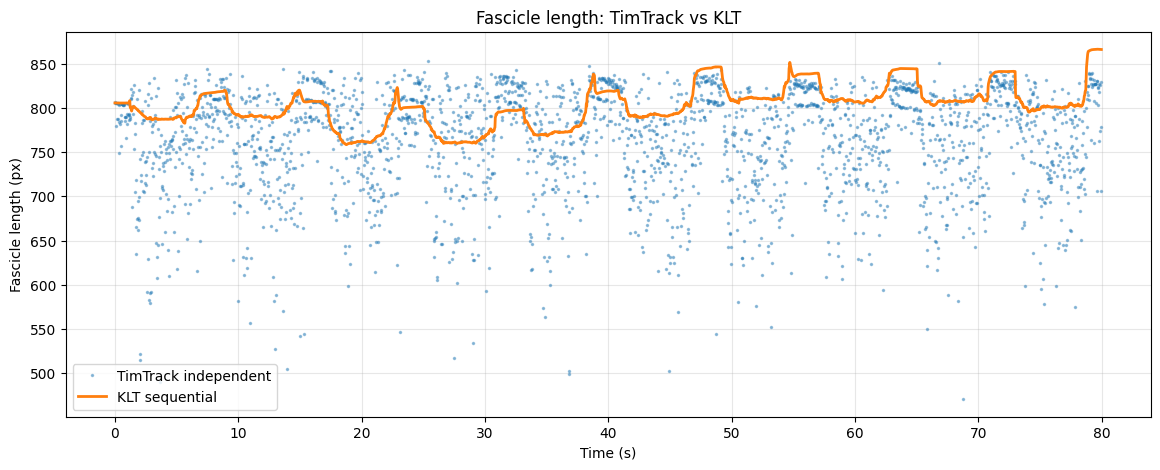

In [21]:
plt.figure(figsize=(14, 5))

plt.plot(time_arr, tim_length, ".", markersize=3, alpha=0.4, label="TimTrack independent")
plt.plot(time_arr, klt_length, "-", linewidth=2, label="KLT sequential")

plt.xlabel("Time (s)")
plt.ylabel("Fascicle length (px)")
plt.title("Fascicle length: TimTrack vs KLT")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

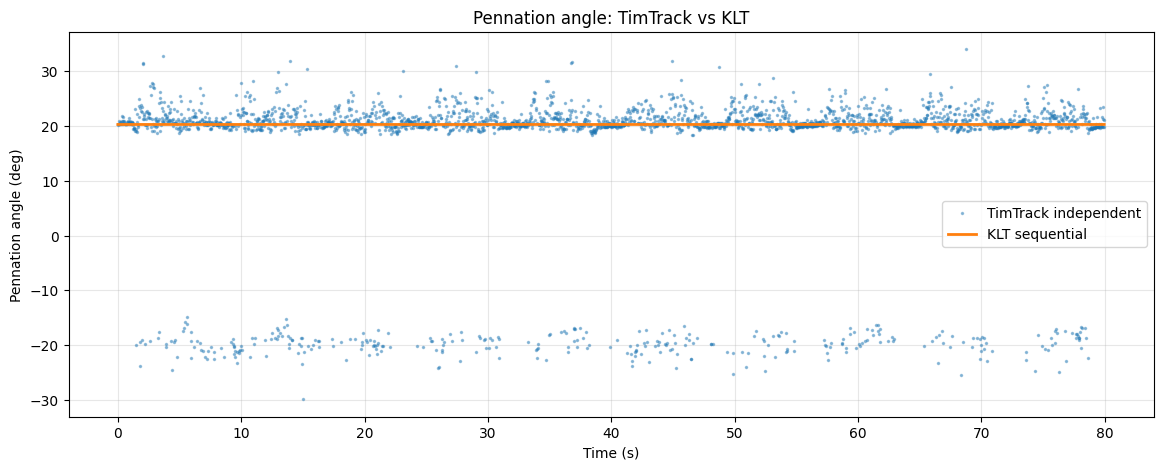

In [22]:
plt.figure(figsize=(14, 5))

plt.plot(time_arr, tim_pennation, ".", markersize=3, alpha=0.4, label="TimTrack independent")
plt.plot(time_arr, klt_pennation, "-", linewidth=2, label="KLT sequential")

plt.xlabel("Time (s)")
plt.ylabel("Pennation angle (deg)")
plt.title("Pennation angle: TimTrack vs KLT")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

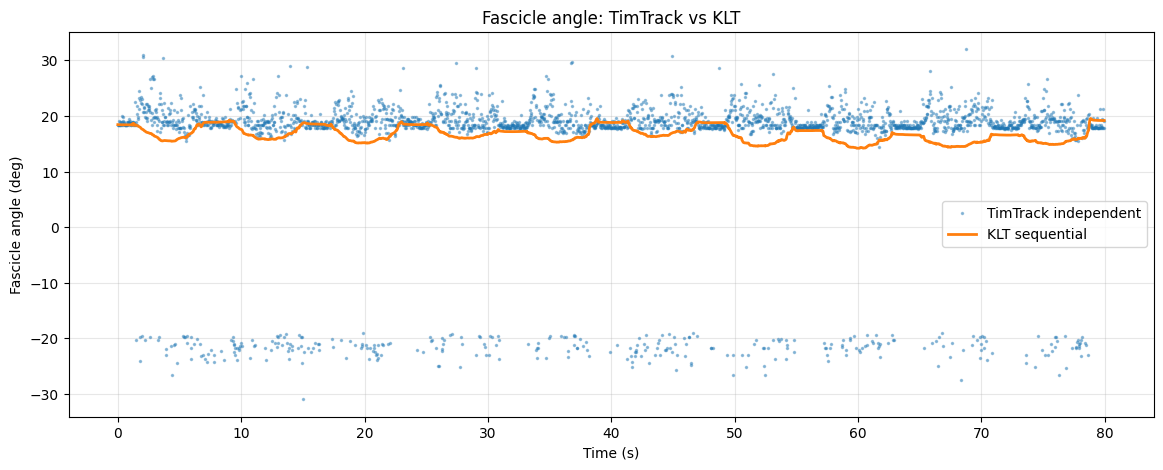

In [23]:
plt.figure(figsize=(14, 5))

plt.plot(time_arr, tim_fascicle_angle, ".", markersize=3, alpha=0.4, label="TimTrack independent")
plt.plot(time_arr, klt_fascicle_angle, "-", linewidth=2, label="KLT sequential")

plt.xlabel("Time (s)")
plt.ylabel("Fascicle angle (deg)")
plt.title("Fascicle angle: TimTrack vs KLT")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
valid_klt_indices = np.where(klt_success)[0]

if len(valid_klt_indices) == 0:
    raise RuntimeError("No successful KLT frames to visualize.")

selected_result_indices = [
    valid_klt_indices[0],
    valid_klt_indices[len(valid_klt_indices) // 2],
    valid_klt_indices[-1],
]

print("Selected result indices:", selected_result_indices)
print("Selected frame numbers:", [int(frames_arr[i]) for i in selected_result_indices])

Selected result indices: [np.int64(0), np.int64(1333), np.int64(2666)]
Selected frame numbers: [0, 1333, 2666]


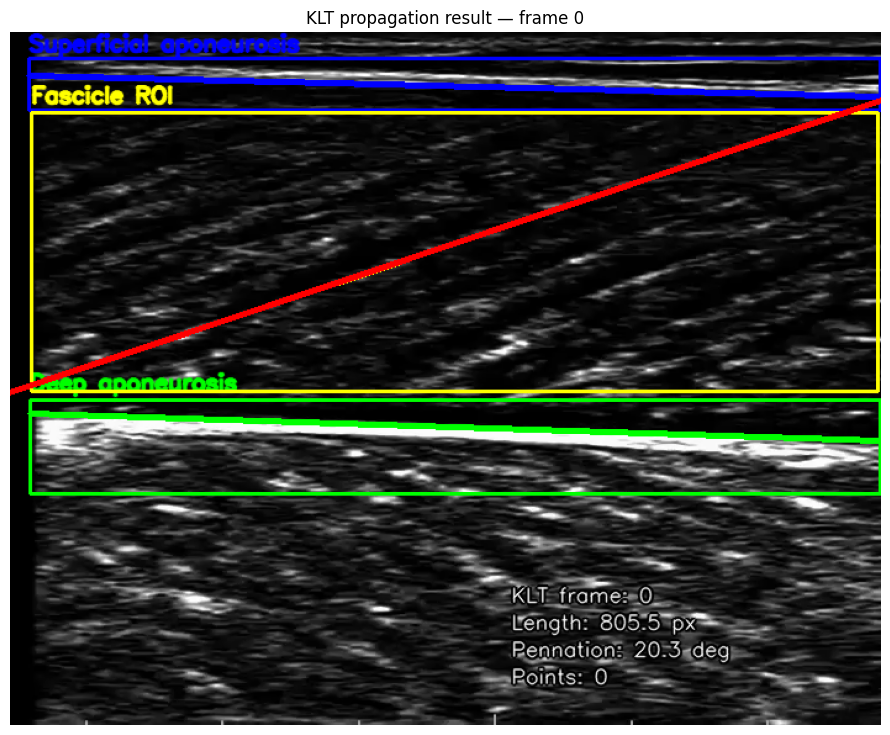

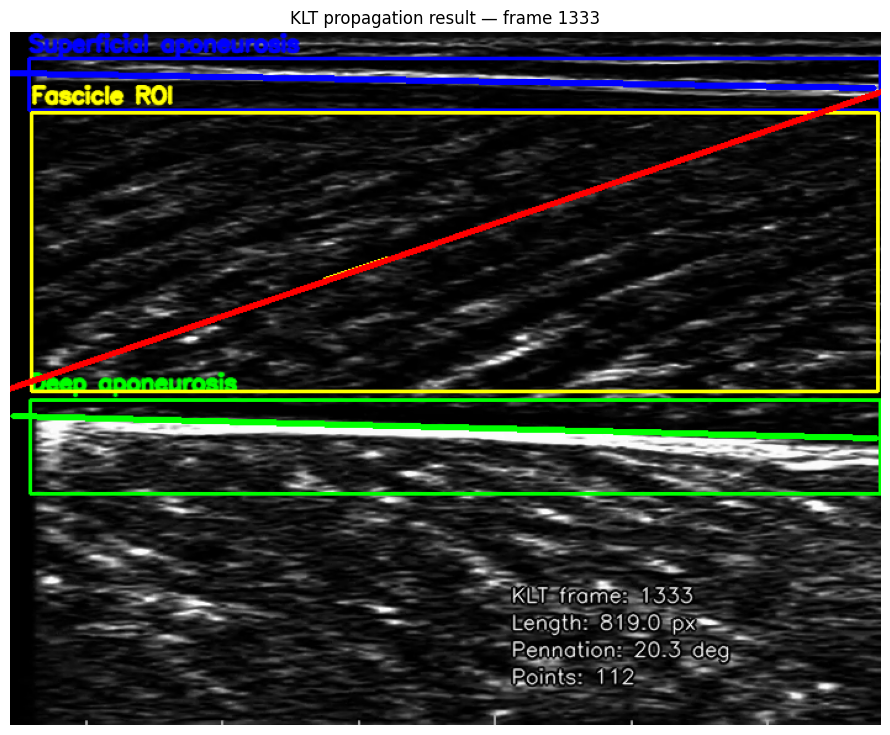

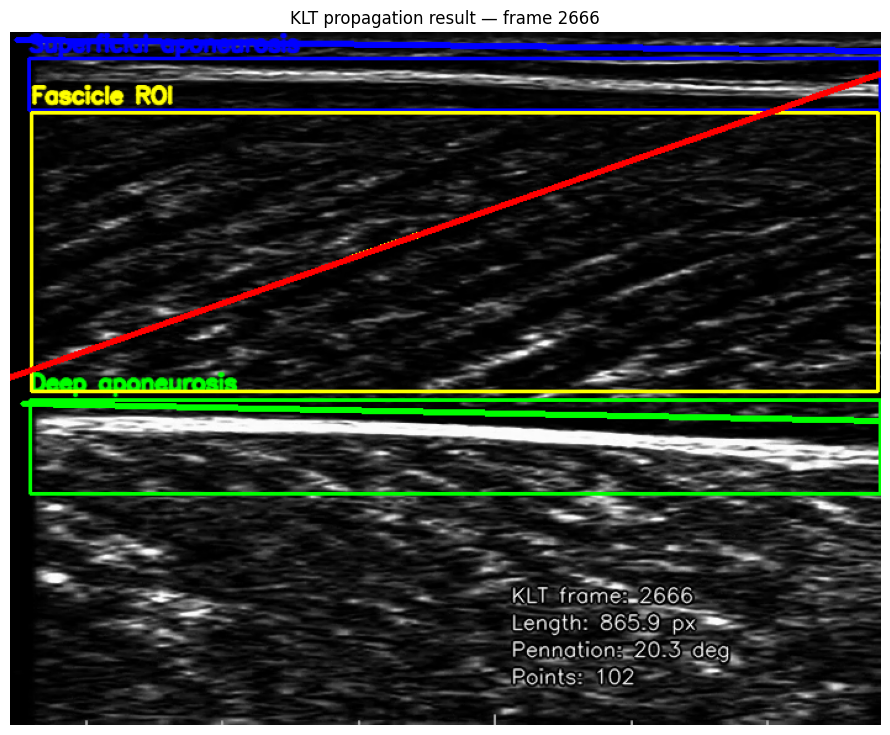

In [25]:
for result_idx in selected_result_indices:
    frame_idx = int(frames_arr[result_idx])

    cap = cv2.VideoCapture(str(VIDEO_PATH))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print("Could not read frame", frame_idx)
        continue

    if frame.ndim == 3:
        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    else:
        frame_gray = frame.copy()

    vis = roi.draw_rois(frame_gray, rois)

    # KLT geometry
    ut.draw_line_on_image(vis, klt_sup_apo_lines[result_idx], color=(255, 0, 0), thickness=3)
    ut.draw_line_on_image(vis, klt_deep_apo_lines[result_idx], color=(0, 255, 0), thickness=3)
    ut.draw_line_on_image(vis, klt_fascicle_lines[result_idx], color=(0, 255, 255), thickness=3)
    ut.draw_line_on_image(vis, klt_fascicle_segments[result_idx], color=(0, 0, 255), thickness=4)

    ut.draw_points_on_image(
        vis,
        np.vstack([
            klt_sup_attachments[result_idx],
            klt_deep_attachments[result_idx],
        ]),
        color=(0, 0, 255),
        radius=6,
    )

    text_lines = [
        f"KLT frame: {frame_idx}",
        f"Length: {klt_length[result_idx]:.1f} px",
        f"Pennation: {klt_pennation[result_idx]:.1f} deg",
        f"Points: {klt_n_points[result_idx]}",
    ]

    ut.put_text_lines_on_image(
        vis,
        text_lines,
        origin=(frame_gray.shape[1] - 300, frame_gray.shape[0] - 100),
        line_spacing=22,
        font_scale=0.55,
        color=(255, 255, 255),
        outline_color=(0, 0, 0),
    )

    plt.figure(figsize=(16, 9))
    plt.imshow(vis[..., ::-1])
    plt.title(f"KLT propagation result — frame {frame_idx}")
    plt.axis("off")
    plt.show()

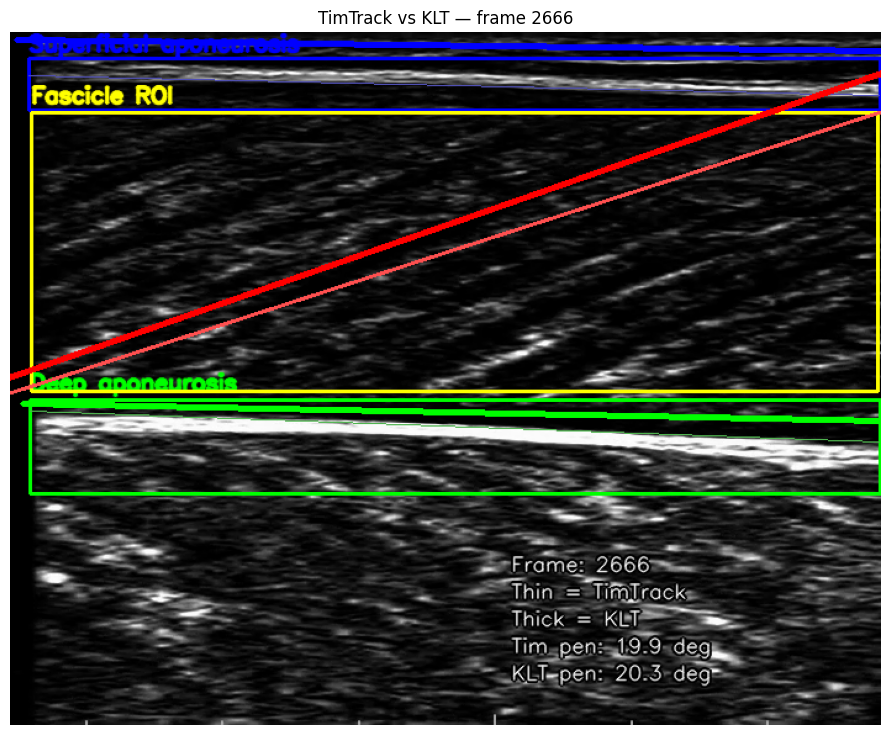

In [26]:
comparison_idx = selected_result_indices[-1]
comparison_frame_idx = int(frames_arr[comparison_idx])

cap = cv2.VideoCapture(str(VIDEO_PATH))
cap.set(cv2.CAP_PROP_POS_FRAMES, comparison_frame_idx)
ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError(f"Could not read frame {comparison_frame_idx}")

if frame.ndim == 3:
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
else:
    frame_gray = frame.copy()

vis = roi.draw_rois(frame_gray, rois)

# TimTrack in thin lines
ut.draw_line_on_image(vis, tim_sup_apo_lines[comparison_idx], color=(180, 80, 80), thickness=1)
ut.draw_line_on_image(vis, tim_deep_apo_lines[comparison_idx], color=(80, 180, 80), thickness=1)
ut.draw_line_on_image(vis, tim_fascicle_segments[comparison_idx], color=(80, 80, 255), thickness=2)

# KLT in thick lines
ut.draw_line_on_image(vis, klt_sup_apo_lines[comparison_idx], color=(255, 0, 0), thickness=3)
ut.draw_line_on_image(vis, klt_deep_apo_lines[comparison_idx], color=(0, 255, 0), thickness=3)
ut.draw_line_on_image(vis, klt_fascicle_segments[comparison_idx], color=(0, 0, 255), thickness=4)

text_lines = [
    f"Frame: {comparison_frame_idx}",
    "Thin = TimTrack",
    "Thick = KLT",
    f"Tim pen: {tim_pennation[comparison_idx]:.1f} deg",
    f"KLT pen: {klt_pennation[comparison_idx]:.1f} deg",
]

ut.put_text_lines_on_image(
    vis,
    text_lines,
    origin=(frame_gray.shape[1] - 300, frame_gray.shape[0] - 125),
    line_spacing=22,
    font_scale=0.55,
    color=(255, 255, 255),
    outline_color=(0, 0, 0),
)

plt.figure(figsize=(16, 9))
plt.imshow(vis[..., ::-1])
plt.title(f"TimTrack vs KLT — frame {comparison_frame_idx}")
plt.axis("off")
plt.show()

In [27]:
loaded_klt = np.load(OUT_NPZ, allow_pickle=True)

print("Loaded:", OUT_NPZ)
print("Keys:")
for key in loaded_klt.files:
    print(" -", key, loaded_klt[key].shape)

print("\nReload check:")
print("Success rate:", 100 * np.mean(loaded_klt["success"]), "%")
print("Mean KLT length:", np.nanmean(loaded_klt["fascicle_length_px"]))
print("Mean KLT pennation:", np.nanmean(loaded_klt["pennation_angle_deg"]))

Loaded: /Users/grosbedou/PycharmProjects/NDORMS/results/klt_sequence_features_arrays.npz
Keys:
 - frame (2667,)
 - time_s (2667,)
 - success (2667,)
 - klt_dx (2667,)
 - klt_dy (2667,)
 - klt_n_points (2667,)
 - klt_affine_used (2667,)
 - sup_apo_lines (2667, 4)
 - deep_apo_lines (2667, 4)
 - fascicle_lines (2667, 4)
 - fascicle_segments (2667, 4)
 - sup_attachments (2667, 2)
 - deep_attachments (2667, 2)
 - fascicle_length_px (2667,)
 - fascicle_angle_deg (2667,)
 - deep_apo_angle_deg (2667,)
 - pennation_angle_deg (2667,)

Reload check:
Success rate: 100.0 %
Mean KLT length: 802.2785
Mean KLT pennation: 20.267447


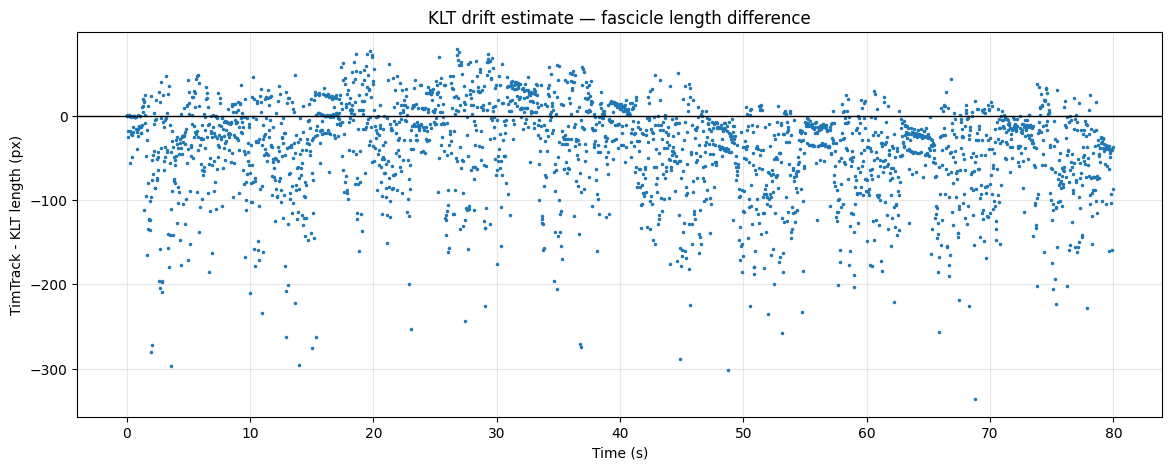

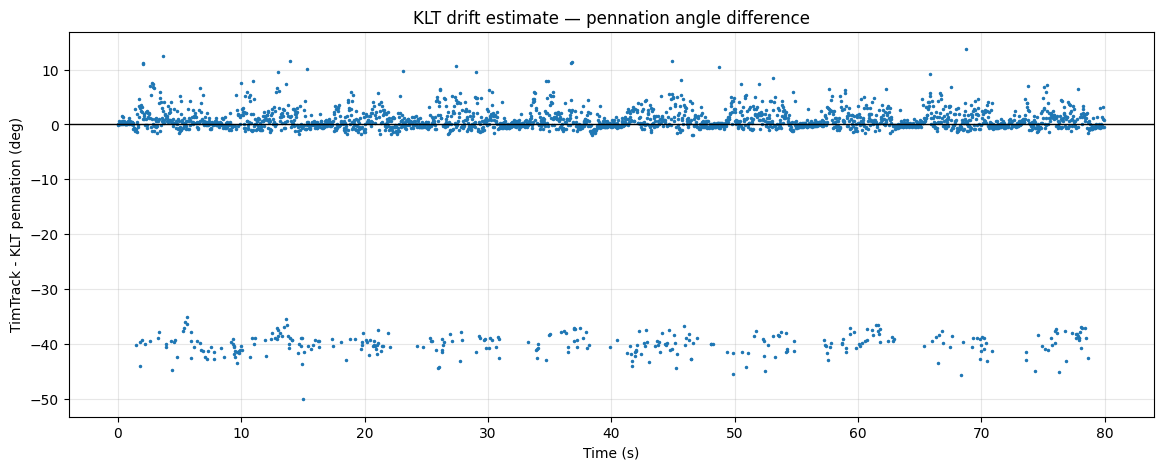

In [28]:
tim_minus_klt_length = tim_length - klt_length
tim_minus_klt_pen = tim_pennation - klt_pennation
tim_minus_klt_angle = tim_fascicle_angle - klt_fascicle_angle

plt.figure(figsize=(14, 5))
plt.plot(time_arr, tim_minus_klt_length, ".", markersize=3)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("TimTrack - KLT length (px)")
plt.title("KLT drift estimate — fascicle length difference")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(time_arr, tim_minus_klt_pen, ".", markersize=3)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("TimTrack - KLT pennation (deg)")
plt.title("KLT drift estimate — pennation angle difference")
plt.grid(True, alpha=0.3)
plt.show()

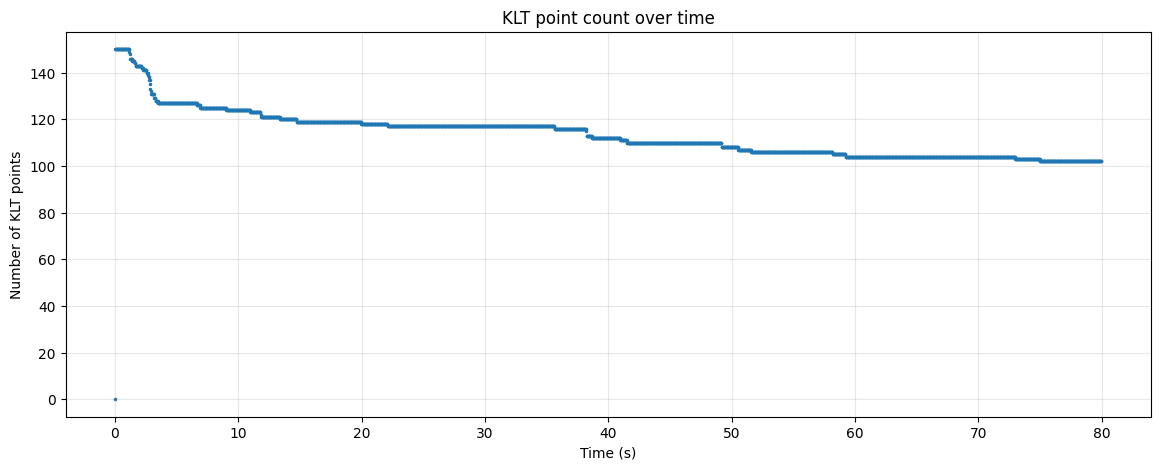

In [29]:
plt.figure(figsize=(14, 5))
plt.plot(time_arr, klt_n_points, ".", markersize=3)
plt.xlabel("Time (s)")
plt.ylabel("Number of KLT points")
plt.title("KLT point count over time")
plt.grid(True, alpha=0.3)
plt.show()